In [1]:
import xarray as xr
from daz_iono import *
from lics_unwrap import *
from scipy.constants import speed_of_light
import numpy as np
from scipy.interpolate import griddata
from LiCSAR_misc import *
import framecare as fc
from scipy.interpolate import interp1d

def get_inc_frame(frame, heading=False):
    '''will get the incidence angle 2d xr.datarray
    if heading==True: return also heading raster
    '''
    metadir = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
    Ufile = os.path.join(metadir, frame + '.geo.U.tif')
    U = load_tif2xr(Ufile)
    U = U.where(U != 0)
    inc = U.copy()
    inc.values = np.degrees(np.arccos(U.values))
    if heading:
        Efile = os.path.join(metadir, frame + '.geo.E.tif')
        Nfile = os.path.join(metadir, frame + '.geo.N.tif')
        E = load_tif2xr(Efile)
        N = load_tif2xr(Nfile)
        E = E.where(E != 0)
        N = N.where(N != 0)
        heading = N.copy(deep=True)
        heading.values = np.degrees(np.arctan2(E, N)) + 90
        return inc, heading
    else:
        return inc



setting pyproj data directory


In [3]:
frame='116A_05207_252525'
epoch='20160124'
# frame='021D_05266_252525'
epoch='20160130'
metadir = os.path.join('/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products', str(int(frame[:3])), frame, 'metadata')
metafile = os.path.join(metadir,'metadata.txt')
#
center_time=grep1line('center_time',metafile).split('=')[1]
acqtime = pd.to_datetime(str(epoch) + 'T' + center_time)

In [14]:
tecxr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True)

In [20]:
acqtime

Timestamp('2016-01-30 15:26:28.278230')

In [16]:
xarray.DataArraytime: 25lat: 71lon: 73

<xarray.DataArray (time: 25, lat: 71, lon: 73)>
array([[[  7.60000000e+16,   7.60000000e+16,   7.60000000e+16, ...,
           7.50000000e+16,   7.60000000e+16,   7.60000000e+16],
        [  7.70000000e+16,   7.80000000e+16,   7.90000000e+16, ...,
           7.50000000e+16,   7.60000000e+16,   7.70000000e+16],
        [  7.50000000e+16,   7.60000000e+16,   7.80000000e+16, ...,
           7.00000000e+16,   7.20000000e+16,   7.50000000e+16],
        ..., 
        [  1.59000000e+17,   1.61000000e+17,   1.63000000e+17, ...,
           1.53000000e+17,   1.56000000e+17,   1.59000000e+17],
        [  1.44000000e+17,   1.45000000e+17,   1.47000000e+17, ...,
           1.40000000e+17,   1.42000000e+17,   1.44000000e+17],
        [  1.33000000e+17,   1.33000000e+17,   1.34000000e+17, ...,
           1.31000000e+17,   1.32000000e+17,   1.33000000e+17]],

       [[  6.10000000e+16,   6.00000000e+16,   6.00000000e+16, ...,
           6.10000000e+16,   6.10000000e+16,   6.10000000e+16],
        [  6.40000000e+16,   6.30000000e+16,   6.20000000e+16, ...,
           6.50000000e+16,   6.40000000e+16,   6.40000000e+16],
        [  6.50000000e+16,   6.40000000e+16,   6.30000000e+16, ...,
           6.50000000e+16,   6.50000000e+16,   6.50000000e+16],
...
        [  1.77000000e+17,   1.82000000e+17,   1.87000000e+17, ...,
           1.65000000e+17,   1.71000000e+17,   1.77000000e+17],
        [  1.66000000e+17,   1.69000000e+17,   1.72000000e+17, ...,
           1.60000000e+17,   1.63000000e+17,   1.66000000e+17],
        [  1.56000000e+17,   1.57000000e+17,   1.58000000e+17, ...,
           1.54000000e+17,   1.55000000e+17,   1.56000000e+17]],

       [[  8.40000000e+16,   8.40000000e+16,   8.30000000e+16, ...,
           8.40000000e+16,   8.40000000e+16,   8.40000000e+16],
        [  8.90000000e+16,   8.90000000e+16,   8.90000000e+16, ...,
           8.70000000e+16,   8.80000000e+16,   8.90000000e+16],
        [  8.90000000e+16,   9.10000000e+16,   9.20000000e+16, ...,
           8.60000000e+16,   8.70000000e+16,   8.90000000e+16],
        ..., 
        [  1.73000000e+17,   1.77000000e+17,   1.80000000e+17, ...,
           1.66000000e+17,   1.70000000e+17,   1.73000000e+17],
        [  1.62000000e+17,   1.64000000e+17,   1.65000000e+17, ...,
           1.58000000e+17,   1.60000000e+17,   1.62000000e+17],
        [  1.49000000e+17,   1.50000000e+17,   1.50000000e+17, ...,
           1.48000000e+17,   1.49000000e+17,   1.49000000e+17]]])
Coordinates:
  * time     (time) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 20.0 21.0 22.0 23.0 24.0
  * lon      (lon) float64 -180.0 -175.0 -170.0 -165.0 ... 170.0 175.0 180.0
  * lat      (lat) float64 87.5 85.0 82.5 80.0 77.5 ... -80.0 -82.5 -85.0 -87.5

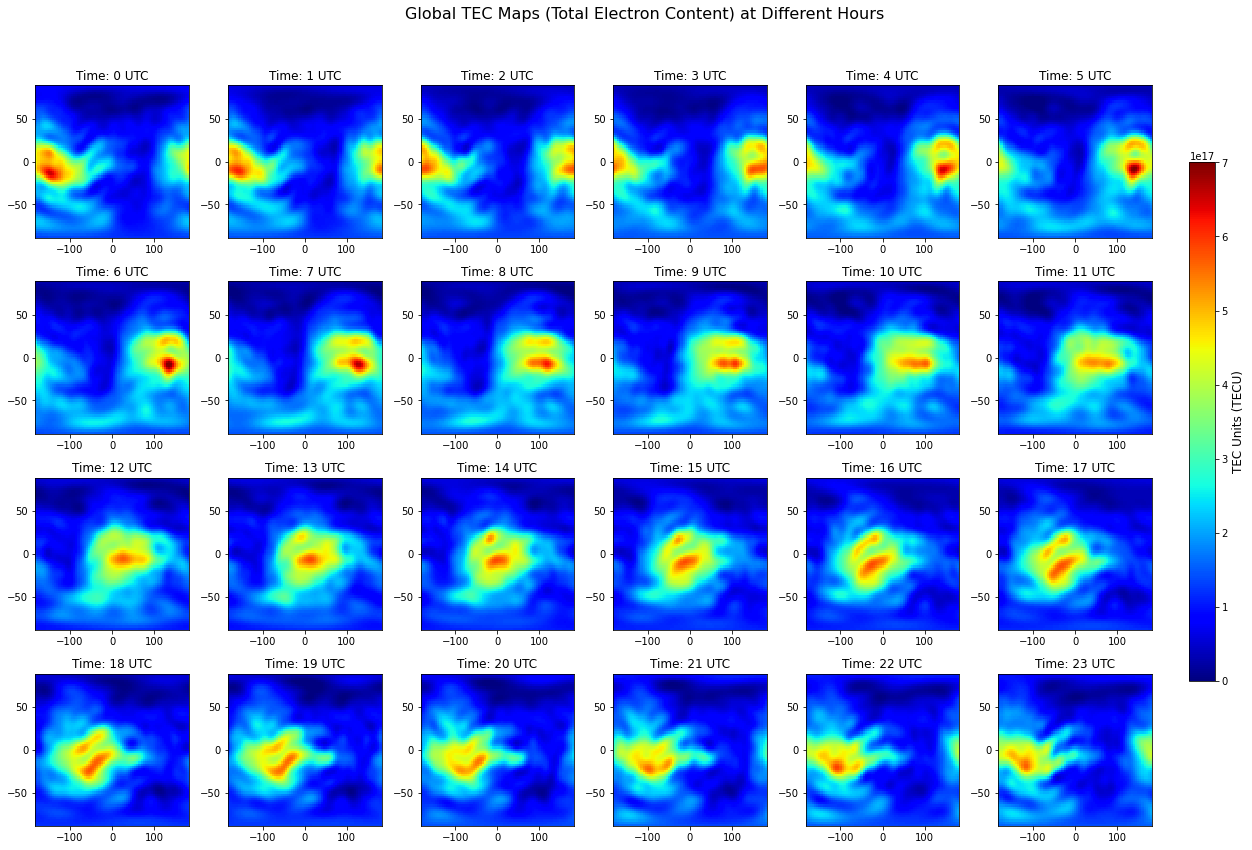

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Define the figure and axes (4 rows, 6 columns)
fig, axes = plt.subplots(4, 6, figsize=(18, 12))

# Adjust layout
fig.suptitle("Global TEC Maps (Total Electron Content) at Different Hours", fontsize=16)

# Determine vmin and vmax for a consistent color scale
vmin = tecxr.min().values
vmax = tecxr.max().values

# Loop through time steps and plot on subplots
for i, ax in enumerate(axes.flat):
    if i < len(tecxr.time):
        # Select the TEC map at time `i`
        tecxr_selected = tecxr.sel(time=tecxr.time[i])

        # Plot on the current axis with fixed vmin/vmax
        im = tecxr_selected.plot(ax=ax, cmap='jet', add_colorbar=False, vmin=0, vmax=7e17)
        
        # Set title as time step
        ax.set_title(f"Time: {int(tecxr.time[i].values)} UTC")
        
        # Remove axis labels for cleaner visualization
        ax.set_xlabel("")
        ax.set_ylabel("")
    else:
        ax.axis("off")  # Hide unused subplots if any

# Create a single colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)  # Assign the colorbar object
cbar.set_label("TEC Units (TECU)", fontsize=12)

# Set the colorbar range from 0 to 7e17
im.set_clim(0, 7e17)  # Correct method to apply limits

# Adjust spacing
plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Leave space for the colorbar
plt.show()


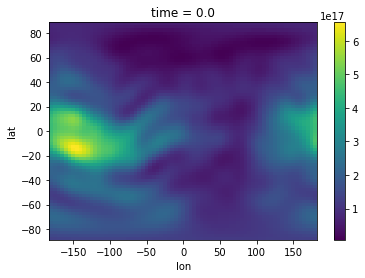

In [17]:
tecxr[0].plot()

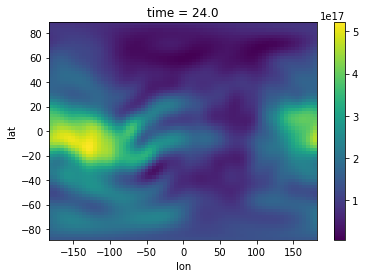

In [19]:
tecxr[24].plot()

In [6]:
acqtime

Timestamp('2016-01-30 15:26:28.278230')

In [7]:
#The files are labeled by doy-of-year number and 2-digit year (e.g. jpliDOY0.YYi.nc).


In [24]:
def download_code_data_JHR(acqtime, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM'):
    #lastrings = ['I', 'N']
    ffound = False
    if not ffound:
        filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
        url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wgotfile = wget.download(url, out=storedir)
                except:
                    print('error during wget download')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    if not ffound:
        print('no CODE layer found for '+filename)
        return False
    if not os.path.exists(ionix):
        rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
    if not os.path.exists(ionix):
        print('ERROR: maybe you do not have 7za installed')
        return False
    return ionix
ionix_JHR = download_code_data_JHR(acqtime)
ionix = download_code_data(acqtime)

In [25]:
import xarray as xr

# Open the NetCDF file
ds = xr.open_dataset(ionix_JHR)

# Print dataset summary
print(ds)


<xarray.Dataset>
Dimensions:    (nepochs: 96, nlats: 180, nlons: 360)
Coordinates:
    time       (nepochs) float64 ...
    lat        (nlats) float32 ...
    lon        (nlons) float32 ...
Dimensions without coordinates: nepochs, nlats, nlons
Data variables:
    varepochs  (nepochs) object ...
    tecmap     (nepochs, nlats, nlons) float32 ...
    tecflag    (nepochs, nlats, nlons) int8 ...
Attributes:
    CreationDateUTC:  2023-03-15 21:40:25.142426
    OutputFileName:   jpld0300.16i.nc
    InputFileName:    160130_0000_160131_0000.tecgrds.txt
    Description:      This netCDF4 file was converted from tecgrds file, cont...


In [10]:
print(ds.variables)

Frozen({'varepochs': <xarray.Variable (nepochs: 96)>
[96 values with dtype=object]
Attributes:
    description:  begin time of each 15-minute interval
    units:        yyyy/mm/dd_HH:MM:SS UT, 'time': <xarray.Variable (nepochs: 96)>
[96 values with dtype=float64]
Attributes:
    description:  begin time of each 15-minute interval
    units:        seconds past J2000 (1/1/2000 12:00 UT), 'lat': <xarray.Variable (nlats: 180)>
[180 values with dtype=float32]
Attributes:
    units:          degrees north
    standard_name:  latitude, 'lon': <xarray.Variable (nlons: 360)>
[360 values with dtype=float32]
Attributes:
    units:          degrees east
    standard_name:  longitude, 'tecmap': <xarray.Variable (nepochs: 96, nlats: 180, nlons: 360)>
[6220800 values with dtype=float32]
Attributes:
    units:    TECU (1x10^16 el m-2), 'tecflag': <xarray.Variable (nepochs: 96, nlats: 180, nlons: 360)>
[6220800 values with dtype=int8]
Attributes:
    description:  TEC data quality flag. 0 represents g

In [12]:
print("Time epochs:", ds['time'].values)

Time epochs: [  5.07384000e+08   5.07384900e+08   5.07385800e+08   5.07386700e+08
   5.07387600e+08   5.07388500e+08   5.07389400e+08   5.07390300e+08
   5.07391200e+08   5.07392100e+08   5.07393000e+08   5.07393900e+08
   5.07394800e+08   5.07395700e+08   5.07396600e+08   5.07397500e+08
   5.07398400e+08   5.07399300e+08   5.07400200e+08   5.07401100e+08
   5.07402000e+08   5.07402900e+08   5.07403800e+08   5.07404700e+08
   5.07405600e+08   5.07406500e+08   5.07407400e+08   5.07408300e+08
   5.07409200e+08   5.07410100e+08   5.07411000e+08   5.07411900e+08
   5.07412800e+08   5.07413700e+08   5.07414600e+08   5.07415500e+08
   5.07416400e+08   5.07417300e+08   5.07418200e+08   5.07419100e+08
   5.07420000e+08   5.07420900e+08   5.07421800e+08   5.07422700e+08
   5.07423600e+08   5.07424500e+08   5.07425400e+08   5.07426300e+08
   5.07427200e+08   5.07428100e+08   5.07429000e+08   5.07429900e+08
   5.07430800e+08   5.07431700e+08   5.07432600e+08   5.07433500e+08
   5.07434400e+08   5

In [21]:
import pandas as pd
import numpy as np

# Extract time values from the dataset
time_values = ds['time'].values  # Assuming 'ds' is your xarray dataset

# Convert to datetime (J2000 starts at 2000-01-01 12:00:00 UTC)
converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')

# Print first 5 timestamps
print(converted_times)


DatetimeIndex(['2016-01-30 00:00:00', '2016-01-30 00:15:00',
               '2016-01-30 00:30:00', '2016-01-30 00:45:00',
               '2016-01-30 01:00:00', '2016-01-30 01:15:00',
               '2016-01-30 01:30:00', '2016-01-30 01:45:00',
               '2016-01-30 02:00:00', '2016-01-30 02:15:00',
               '2016-01-30 02:30:00', '2016-01-30 02:45:00',
               '2016-01-30 03:00:00', '2016-01-30 03:15:00',
               '2016-01-30 03:30:00', '2016-01-30 03:45:00',
               '2016-01-30 04:00:00', '2016-01-30 04:15:00',
               '2016-01-30 04:30:00', '2016-01-30 04:45:00',
               '2016-01-30 05:00:00', '2016-01-30 05:15:00',
               '2016-01-30 05:30:00', '2016-01-30 05:45:00',
               '2016-01-30 06:00:00', '2016-01-30 06:15:00',
               '2016-01-30 06:30:00', '2016-01-30 06:45:00',
               '2016-01-30 07:00:00', '2016-01-30 07:15:00',
               '2016-01-30 07:30:00', '2016-01-30 07:45:00',
               '2016-01-

In [23]:
tec_data

<xarray.DataArray 'tecmap' (nlats: 180, nlons: 360)>
[64800 values with dtype=float32]
Coordinates:
    time     float64 5.075e+08
    lat      (nlats) float32 ...
    lon      (nlons) float32 ...
Dimensions without coordinates: nlats, nlons
Attributes:
    units:    TECU (1x10^16 el m-2)

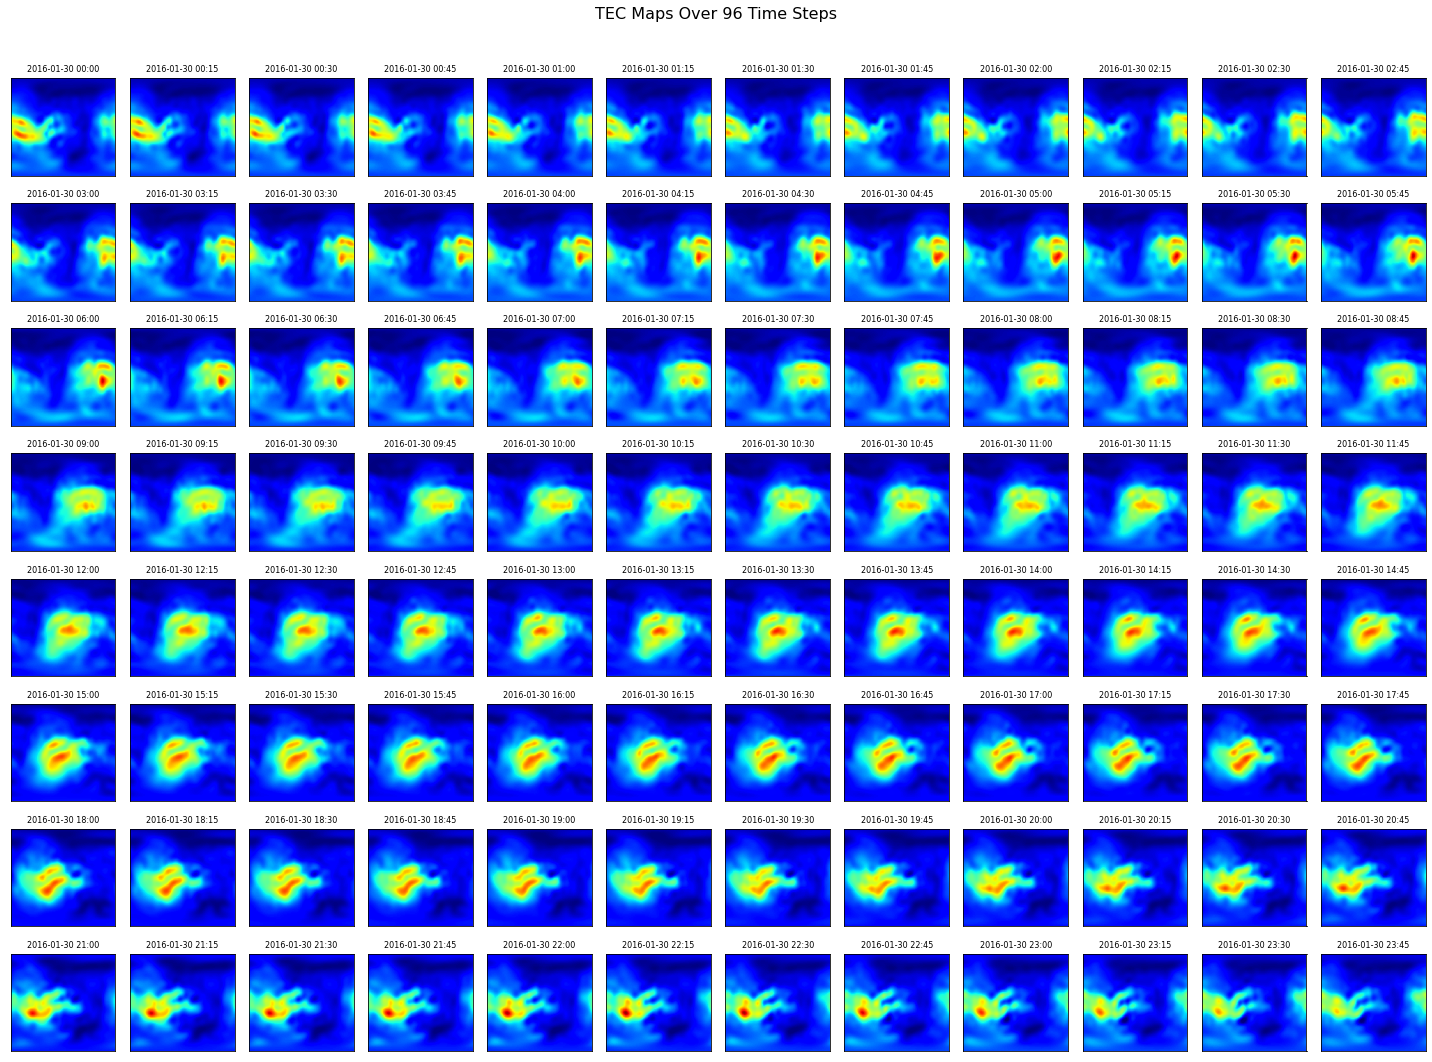

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

# Open the NetCDF file
ds = xr.open_dataset(ionix_JHR)
ds['tecmap'] = ds['tecmap'] * 1e16
# Extract time values from the dataset
time_values = ds['time'].values

# Convert time epochs to readable datetime format
converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')

# Define the number of rows and columns for subplots
nrows, ncols = 8, 12  # 8x12 grid for 96 images
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 15))
fig.suptitle("TEC Maps Over 96 Time Steps", fontsize=16)

# Flatten the axes for easy iteration
axes = axes.flatten()

# Loop through each time step and plot
for i in range(96):
    ax = axes[i]
    tec_data = ds['tecmap'].isel(nepochs=i)
    
    im = tec_data.plot(x='lon', y='lat', ax=ax, cmap='jet', add_colorbar=False, vmin=0, vmax=7e17)
    ax.set_title(str(converted_times[i])[:16], fontsize=8)  # Shortened datetime string
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [28]:
ds

<xarray.Dataset>
Dimensions:    (nepochs: 96, nlats: 180, nlons: 360)
Coordinates:
    time       (nepochs) float64 5.074e+08 5.074e+08 ... 5.075e+08 5.075e+08
    lat        (nlats) float32 ...
    lon        (nlons) float32 ...
Dimensions without coordinates: nepochs, nlats, nlons
Data variables:
    varepochs  (nepochs) object ...
    tecmap     (nepochs, nlats, nlons) float32 ...
    tecflag    (nepochs, nlats, nlons) int8 ...
Attributes:
    CreationDateUTC:  2023-03-15 21:40:25.142426
    OutputFileName:   jpld0300.16i.nc
    InputFileName:    160130_0000_160131_0000.tecgrds.txt
    Description:      This netCDF4 file was converted from tecgrds file, cont...

In [29]:
ds = xr.open_dataset(ionix_JHR)
ds['tecmap'] = ds['tecmap'] * 1e16

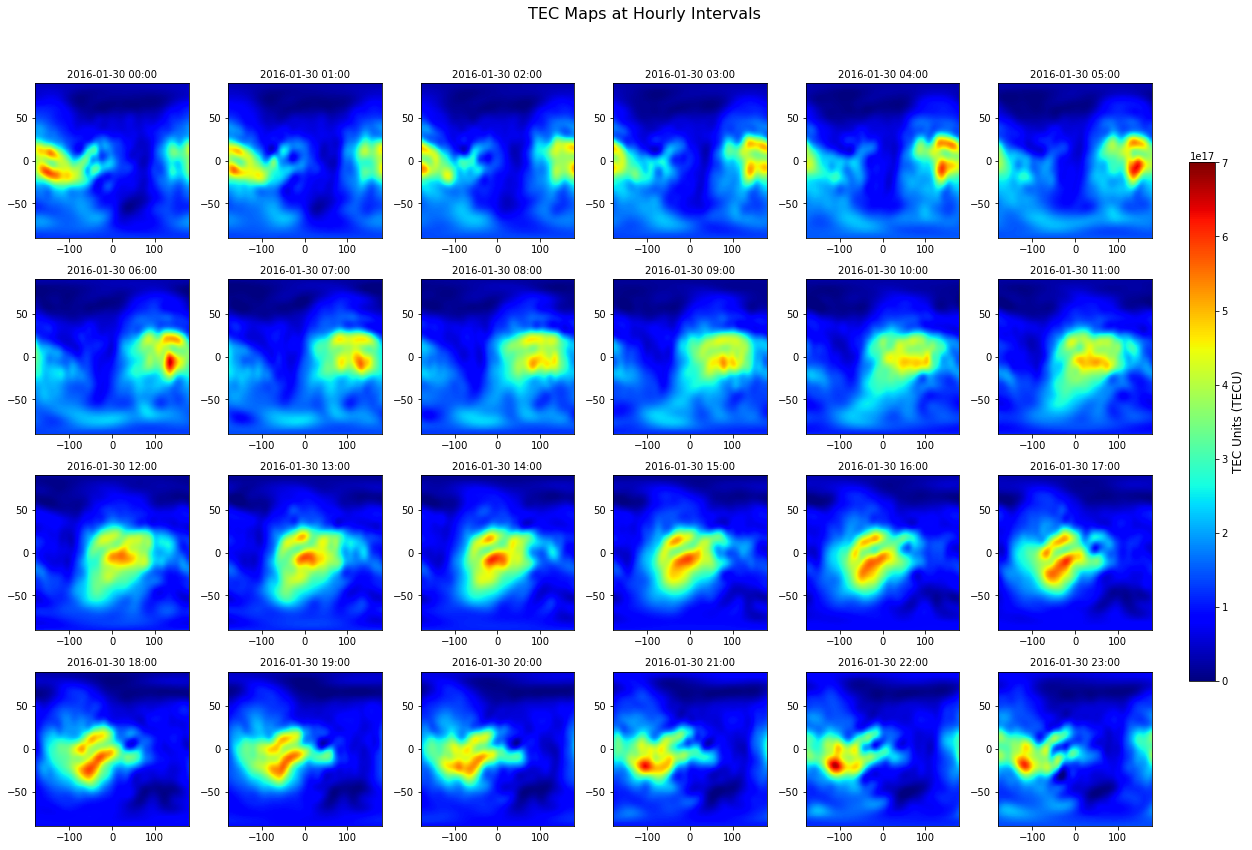

In [30]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
# Open the NetCDF file

# Load the dataset (Replace with the actual path if needed)
# Extract time values from the dataset
time_values = ds['time'].values

# Convert time epochs to readable datetime format
converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')

# Select every 4th time step to get one per hour (assuming 15-minute intervals)
selected_indices = range(0, 96, 4)  # Every 4th epoch (15min * 4 = 1 hour)
selected_times = converted_times[selected_indices]

# Define the number of rows and columns for subplots (6x4 for 24 images)
nrows, ncols = 4, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12))
fig.suptitle("TEC Maps at Hourly Intervals", fontsize=16)

# Flatten the axes for easy iteration
axes = axes.flatten()

# Loop through selected time steps and plot
for idx, i in enumerate(selected_indices):
    ax = axes[idx]
    tec_data = ds['tecmap'].isel(nepochs=i)

    im = tec_data.plot(x='lon', y='lat',ax=ax, cmap='jet', add_colorbar=False, vmin=0, vmax=7e17)
    ax.set_title(str(selected_times[idx])[:16], fontsize=10)  # Shortened datetime
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.set_xticks([])
    # ax.set_yticks([])

# Add a single colorbar to the left
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)  # Assign the colorbar object
cbar.set_label("TEC Units (TECU)", fontsize=12)

# Set the colorbar range from 0 to 7e17
im.set_clim(0, 7e17)  # Correct method to apply limits

# Adjust layout
# Adjust spacing
plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Leave space for the colorbar
plt.show()


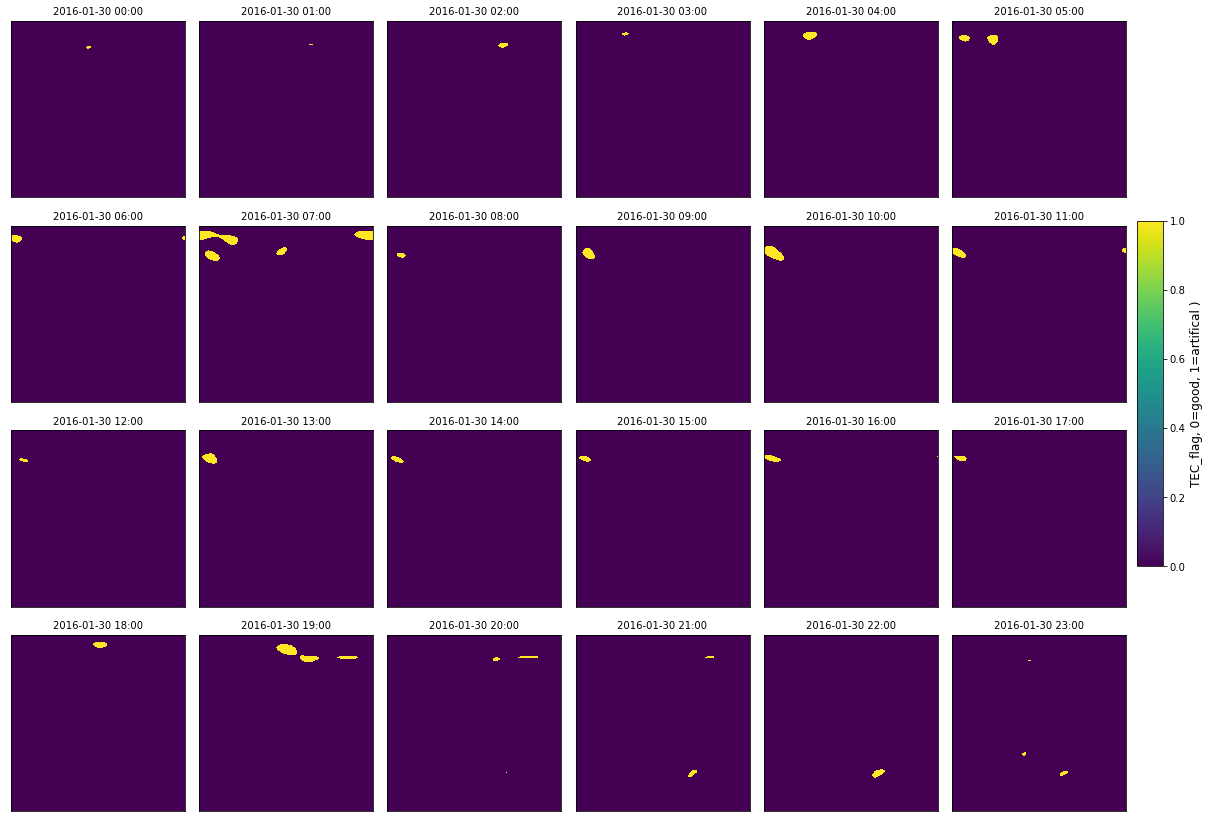

In [17]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset (Replace with the actual path if needed)
# Extract time values from the dataset
time_values = ds['time'].values

# Convert time epochs to readable datetime format
converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')

# Select every 4th time step to get one per hour (assuming 15-minute intervals)
selected_indices = range(0, 96, 4)  # Every 4th epoch (15min * 4 = 1 hour)
selected_times = converted_times[selected_indices]

# Define the number of rows and columns for subplots (6x4 for 24 images)
nrows, ncols = 4, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12))
# fig.suptitle("TEC Maps at Hourly Intervals", fontsize=16)

# Flatten the axes for easy iteration
axes = axes.flatten()

# Loop through selected time steps and plot
for idx, i in enumerate(selected_indices):
    ax = axes[idx]
    tec_data = ds['tecflag'].isel(nepochs=i)

    im = tec_data.plot(x='lon', y='lat',ax=ax, add_colorbar=False, vmin=0, vmax=1)
    ax.set_title(str(selected_times[idx])[:16], fontsize=10)  # Shortened datetime
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

# Add a single colorbar to the left
cbar_ax = fig.add_axes([1, 0.3, 0.02, 0.4])  # Position: [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label("TEC_flag, 0=good, 1=artifical )", fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0.12, 0, 1, 0.96])
plt.show()


In [18]:
###

In [32]:
try:
    tecmaps = get_tecmaps(ionix)
except:
    print('ERROR loading ionix file: '+ionix)
try:
    interval = int(grep1line('INTERVAL',ionix).split()[0])
except:
    print('ERROR, the ionix file '+ionix+' does not contain necessary keywords. Cancelling')

    
timestep = interval/3600
timecoords = np.arange(0.0,24.0+timestep,timestep)  # we expect start/end time being midnight, should be standard for all CODE files?
lat_all = np.arange(87.5,-87.5-2.5,-2.5)
lon_all = np.arange(-180.0,180.0+5,5.0)
tecxr = xr.DataArray(data=tecmaps, dims=['time','lat','lon'],
                    coords=dict(time=timecoords, lon=lon_all, lat=lat_all) )
# interpolate through the nan values
tonan=9999
tecxr.where(tecxr!=tonan)
tecxr=tecxr.interpolate_na(dim="lon", method="linear", fill_value="extrapolate")
tecxr = tecxr*1e+16 # from TECU

In [20]:
# ds.info()
# ds.data_vars
# ds.dims
# ds.coords
# ds.attrs
# ds.tecmap[0].plot()


In [21]:
##arrray:
# ds.tecmap.data
# ds.tecmap.dims
# ds.tecmap.coords
# ds.tecmap.attrs
# ds.coords['lat']


In [34]:
epoch_index = 0  # Change this index to view other epochs
data_array = ds['tecmap'].isel(nepochs=epoch_index)


In [33]:
tecxr[0]

<xarray.DataArray (lat: 71, lon: 73)>
array([[  7.60000000e+16,   7.60000000e+16,   7.60000000e+16, ...,
          7.50000000e+16,   7.60000000e+16,   7.60000000e+16],
       [  7.70000000e+16,   7.80000000e+16,   7.90000000e+16, ...,
          7.50000000e+16,   7.60000000e+16,   7.70000000e+16],
       [  7.50000000e+16,   7.60000000e+16,   7.80000000e+16, ...,
          7.00000000e+16,   7.20000000e+16,   7.50000000e+16],
       ..., 
       [  1.59000000e+17,   1.61000000e+17,   1.63000000e+17, ...,
          1.53000000e+17,   1.56000000e+17,   1.59000000e+17],
       [  1.44000000e+17,   1.45000000e+17,   1.47000000e+17, ...,
          1.40000000e+17,   1.42000000e+17,   1.44000000e+17],
       [  1.33000000e+17,   1.33000000e+17,   1.34000000e+17, ...,
          1.31000000e+17,   1.32000000e+17,   1.33000000e+17]])
Coordinates:
    time     float64 0.0
  * lon      (lon) float64 -180.0 -175.0 -170.0 -165.0 ... 170.0 175.0 180.0
  * lat      (lat) float64 87.5 85.0 82.5 80.0 77.5 ... -80.0 -82.5 -85.0 -87.5

In [35]:
ds['tecmap']

<xarray.DataArray 'tecmap' (nepochs: 96, nlats: 180, nlons: 360)>
array([[[  3.70000008e+16,   3.70000008e+16,   3.70000008e+16, ...,
           3.70000008e+16,   3.70000008e+16,   3.70000008e+16],
        [  3.90000039e+16,   3.90000039e+16,   3.90000039e+16, ...,
           3.90000039e+16,   3.90000039e+16,   3.90000039e+16],
        [  4.09999983e+16,   4.09999983e+16,   4.09999983e+16, ...,
           4.09999983e+16,   4.09999983e+16,   4.09999983e+16],
        ..., 
        [  1.26000004e+17,   1.26000004e+17,   1.26000004e+17, ...,
           1.25000007e+17,   1.26000004e+17,   1.26000004e+17],
        [  1.24000001e+17,   1.24000001e+17,   1.24000001e+17, ...,
           1.24000001e+17,   1.24000001e+17,   1.24000001e+17],
        [  1.23000004e+17,   1.23000004e+17,   1.23000004e+17, ...,
           1.23000004e+17,   1.23000004e+17,   1.23000004e+17]],

       [[  3.20000017e+16,   3.20000017e+16,   3.20000017e+16, ...,
           3.20000017e+16,   3.20000017e+16,   3.20000017e+16],
        [  3.40000026e+16,   3.40000026e+16,   3.40000026e+16, ...,
           3.40000026e+16,   3.40000026e+16,   3.40000026e+16],
        [  3.59999993e+16,   3.59999993e+16,   3.59999993e+16, ...,
           3.59999993e+16,   3.59999993e+16,   3.59999993e+16],
...
        [  1.35000005e+17,   1.35000005e+17,   1.35000005e+17, ...,
           1.35000005e+17,   1.35000005e+17,   1.35000005e+17],
        [  1.33000002e+17,   1.33000002e+17,   1.33000002e+17, ...,
           1.33000002e+17,   1.33000002e+17,   1.33000002e+17],
        [  1.31000007e+17,   1.31000007e+17,   1.31000007e+17, ...,
           1.31000007e+17,   1.31000007e+17,   1.31000007e+17]],

       [[  5.90000044e+16,   5.90000044e+16,   5.90000044e+16, ...,
           5.90000044e+16,   5.90000044e+16,   5.90000044e+16],
        [  6.20000004e+16,   6.20000004e+16,   6.20000004e+16, ...,
           6.20000004e+16,   6.20000004e+16,   6.20000004e+16],
        [  6.30000019e+16,   6.30000019e+16,   6.30000019e+16, ...,
           6.30000019e+16,   6.30000019e+16,   6.30000019e+16],
        ..., 
        [  1.32000004e+17,   1.32000004e+17,   1.32000004e+17, ...,
           1.32000004e+17,   1.32000004e+17,   1.32000004e+17],
        [  1.30000001e+17,   1.30000001e+17,   1.30000001e+17, ...,
           1.28999996e+17,   1.30000001e+17,   1.30000001e+17],
        [  1.28000007e+17,   1.28000007e+17,   1.28000007e+17, ...,
           1.28000007e+17,   1.28000007e+17,   1.28000007e+17]]], dtype=float32)
Coordinates:
    time     (nepochs) float64 5.074e+08 5.074e+08 ... 5.075e+08 5.075e+08
    lat      (nlats) float32 ...
    lon      (nlons) float32 ...
Dimensions without coordinates: nepochs, nlats, nlons
Attributes:
    units:    TECU (1x10^16 el m-2)

In [36]:
tecxr

<xarray.DataArray (time: 25, lat: 71, lon: 73)>
array([[[  7.60000000e+16,   7.60000000e+16,   7.60000000e+16, ...,
           7.50000000e+16,   7.60000000e+16,   7.60000000e+16],
        [  7.70000000e+16,   7.80000000e+16,   7.90000000e+16, ...,
           7.50000000e+16,   7.60000000e+16,   7.70000000e+16],
        [  7.50000000e+16,   7.60000000e+16,   7.80000000e+16, ...,
           7.00000000e+16,   7.20000000e+16,   7.50000000e+16],
        ..., 
        [  1.59000000e+17,   1.61000000e+17,   1.63000000e+17, ...,
           1.53000000e+17,   1.56000000e+17,   1.59000000e+17],
        [  1.44000000e+17,   1.45000000e+17,   1.47000000e+17, ...,
           1.40000000e+17,   1.42000000e+17,   1.44000000e+17],
        [  1.33000000e+17,   1.33000000e+17,   1.34000000e+17, ...,
           1.31000000e+17,   1.32000000e+17,   1.33000000e+17]],

       [[  6.10000000e+16,   6.00000000e+16,   6.00000000e+16, ...,
           6.10000000e+16,   6.10000000e+16,   6.10000000e+16],
        [  6.40000000e+16,   6.30000000e+16,   6.20000000e+16, ...,
           6.50000000e+16,   6.40000000e+16,   6.40000000e+16],
        [  6.50000000e+16,   6.40000000e+16,   6.30000000e+16, ...,
           6.50000000e+16,   6.50000000e+16,   6.50000000e+16],
...
        [  1.77000000e+17,   1.82000000e+17,   1.87000000e+17, ...,
           1.65000000e+17,   1.71000000e+17,   1.77000000e+17],
        [  1.66000000e+17,   1.69000000e+17,   1.72000000e+17, ...,
           1.60000000e+17,   1.63000000e+17,   1.66000000e+17],
        [  1.56000000e+17,   1.57000000e+17,   1.58000000e+17, ...,
           1.54000000e+17,   1.55000000e+17,   1.56000000e+17]],

       [[  8.40000000e+16,   8.40000000e+16,   8.30000000e+16, ...,
           8.40000000e+16,   8.40000000e+16,   8.40000000e+16],
        [  8.90000000e+16,   8.90000000e+16,   8.90000000e+16, ...,
           8.70000000e+16,   8.80000000e+16,   8.90000000e+16],
        [  8.90000000e+16,   9.10000000e+16,   9.20000000e+16, ...,
           8.60000000e+16,   8.70000000e+16,   8.90000000e+16],
        ..., 
        [  1.73000000e+17,   1.77000000e+17,   1.80000000e+17, ...,
           1.66000000e+17,   1.70000000e+17,   1.73000000e+17],
        [  1.62000000e+17,   1.64000000e+17,   1.65000000e+17, ...,
           1.58000000e+17,   1.60000000e+17,   1.62000000e+17],
        [  1.49000000e+17,   1.50000000e+17,   1.50000000e+17, ...,
           1.48000000e+17,   1.49000000e+17,   1.49000000e+17]]])
Coordinates:
  * time     (time) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 20.0 21.0 22.0 23.0 24.0
  * lon      (lon) float64 -180.0 -175.0 -170.0 -165.0 ... 170.0 175.0 180.0
  * lat      (lat) float64 87.5 85.0 82.5 80.0 77.5 ... -80.0 -82.5 -85.0 -87.5

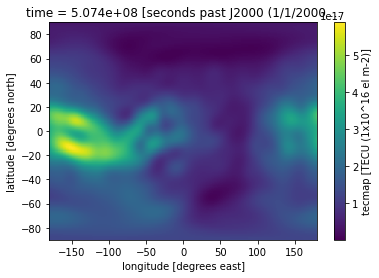

In [37]:
ds['tecmap'][0].plot(x='lon', y='lat')

In [38]:
# Ensure ds['tecmap'][0] has coordinates named explicitly as 'lon' and 'lat'
ds_tecmap0 = ds['tecmap'][0].assign_coords(x='lon', y='lat')

# # Now perform the subtraction
# result = ds_tecmap0 - tecxr[0]


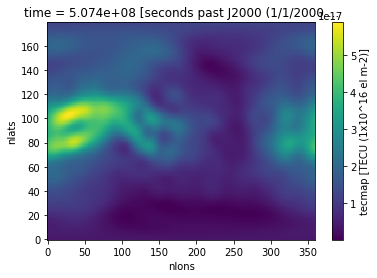

In [39]:
ds_tecmap0.plot()

In [29]:
ds

<xarray.Dataset>
Dimensions:    (nepochs: 96, nlats: 180, nlons: 360)
Coordinates:
    time       (nepochs) float64 5.074e+08 5.074e+08 ... 5.075e+08 5.075e+08
    lat        (nlats) float32 ...
    lon        (nlons) float32 ...
Dimensions without coordinates: nepochs, nlats, nlons
Data variables:
    varepochs  (nepochs) object ...
    tecmap     (nepochs, nlats, nlons) float32 3.7e+16 3.7e+16 ... 1.28e+17
    tecflag    (nepochs, nlats, nlons) int8 ...
Attributes:
    CreationDateUTC:  2023-03-15 21:40:25.142426
    OutputFileName:   jpld0300.16i.nc
    InputFileName:    160130_0000_160131_0000.tecgrds.txt
    Description:      This netCDF4 file was converted from tecgrds file, cont...

In [40]:
ds_new = xr.DataArray(
    ds['tecmap'][0].values, 
    coords={"lat": ds["lat"].values, "lon": ds["lon"].values}, 
    dims=["lat", "lon"]
)
tecxr_da=tecxr[0]
tecxr_interp = tecxr_da.interp_like(ds_new, method='linear')
# Compute the difference
tec_difference = tecxr_interp-ds_new


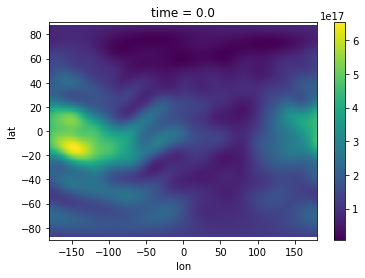

In [41]:
tecxr_interp.plot()

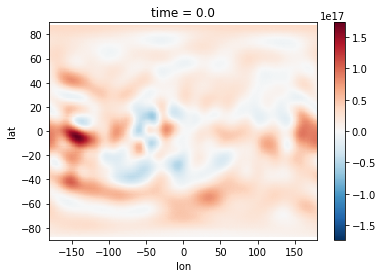

In [42]:
tec_difference.plot()

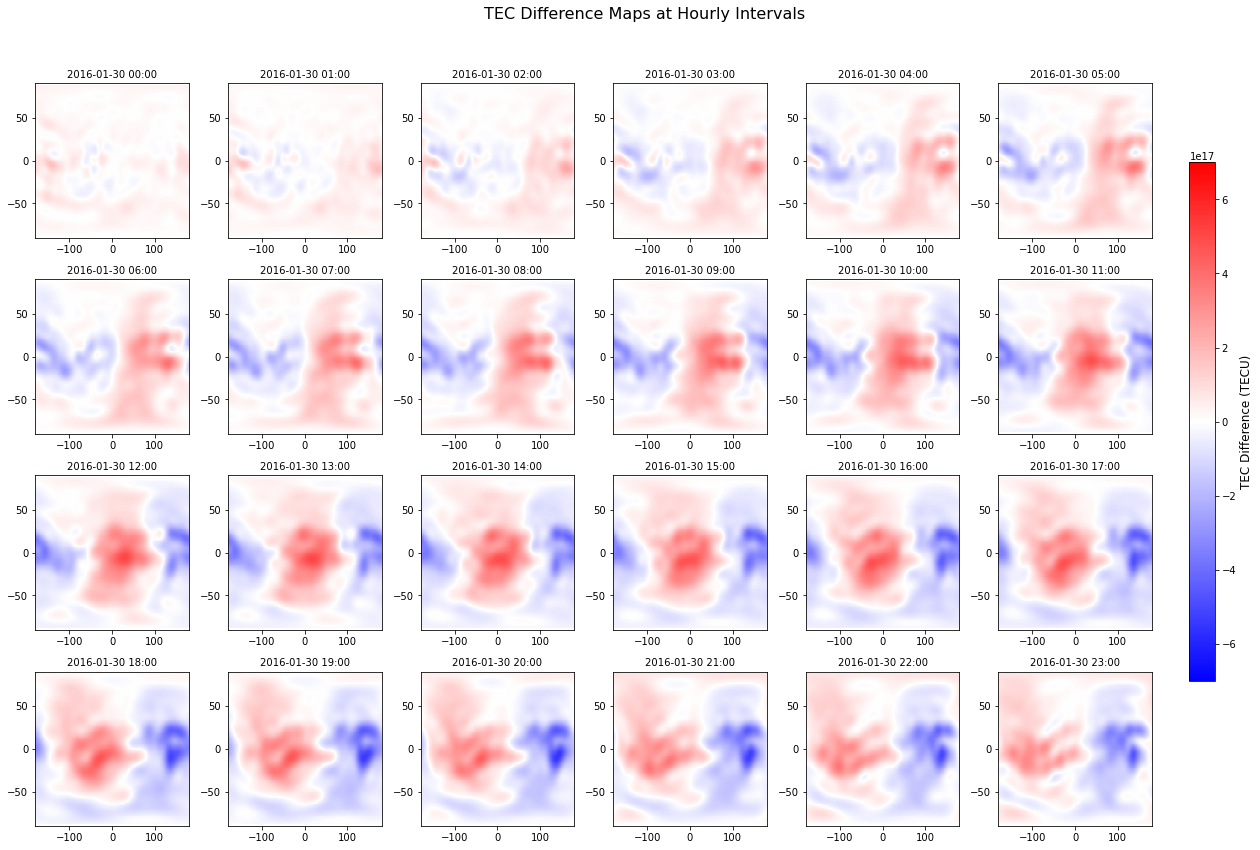

In [43]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# Convert time epochs to datetime
time_values = ds['time'].values
converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')

# Select every 4th time step (hourly)
selected_indices = range(0, 96, 4)
selected_times = converted_times[selected_indices]

# Define figure layout
nrows, ncols = 4, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12))
fig.suptitle("TEC Difference Maps at Hourly Intervals", fontsize=16)

# Flatten axes
axes = axes.flatten()
# Loop through selected time steps
for idx, i in enumerate(selected_indices):
    ax = axes[idx]
    ds_new = xr.DataArray(
        ds['tecmap'][idx].values, 
        coords={"lat": ds["lat"].values, "lon": ds["lon"].values}, 
        dims=["lat", "lon"]
    )
    tecxr_da=tecxr[idx]
    tecxr_interp = tecxr_da.interp_like(ds_new, method='linear')
    # Compute the difference
    tec_difference = tecxr_interp-ds_new
    # Plot the difference
    im = tec_difference.plot(ax=ax, cmap='bwr', add_colorbar=False, vmin=-7e17, vmax=7e17)
    ax.set_title(str(selected_times[idx])[:16], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Add a single colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("TEC Difference (TECU)", fontsize=12)

# Set colorbar range (adjust based on expected differences)
im.set_clim(-7e17, 7e17)  # Adjust limits as needed for better contrast

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

In [44]:
# Convert TEC difference (electrons/m²) to LOS displacement in mm
los_delay_mm = 0.276 * (tec_difference / 1e17)

In [ ]:
# Define figure layout
nrows, ncols = 4, 6
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 12))
#fig.suptitle("TEC Difference Maps at Hourly Intervals", fontsize=16)

# Flatten axes
axes = axes.flatten()
# Loop through selected time steps
for idx, i in enumerate(selected_indices):
    ax = axes[idx]
    ds_new = xr.DataArray(
        ds['tecmap'][idx].values, 
        coords={"lat": ds["lat"].values, "lon": ds["lon"].values}, 
        dims=["lat", "lon"]
    )
    tecxr_da=tecxr[idx]
    tecxr_interp = tecxr_da.interp_like(ds_new, method='linear')
    # Compute the difference
    tec_difference = tecxr_interp-ds_new
    # Plot the difference
    # Plot the LOS delay instead of TEC difference
    los_delay_mm = 0.276 * (tec_difference / 1e17)
    im = los_delay_mm.plot(ax=ax, cmap='bwr', add_colorbar=False, vmin=-2, vmax=2)

    ax.set_title(str(selected_times[idx])[:16], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Add a single colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("LOS Displacement (2-way meter)", fontsize=12)

In [36]:
####let's go to second step!

In [37]:
#This code is used the Ionex to xarray, but in JPLHR we already have .nc format!!

In [38]:
def download_code_data_JHR(acqtime, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM'):
    #lastrings = ['I', 'N']
    ffound = False
    if not ffound:
        filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
        url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        print(ionix)
        print(fullpath)
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wgotfile = wget.download(url, out=storedir)
                except:
                    print('error during wget download')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    if not ffound:
        print('no CODE layer found for '+filename)
        return False
    if not os.path.exists(ionix):
        rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
    if not os.path.exists(ionix):
        print('ERROR: maybe you do not have 7za installed')
        return False
    return ionix

In [39]:
def get_vtec_from_code(acqtime, lat = 0, lon = 0, storedir = '/gws/nopw/j04/nceo_geohazards_vol1/code_iono', return_fullxr = False):
    """ Adapted from Reza Bordbari script, plus using functions from https://notebook.community/daniestevez/jupyter_notebooks/IONEX

    Args:
        acqtime (dt.datetime)
        lat (float)
        lon (float)
        storedir (str)
        return_fullxr (bool): if True, will return full TEC datacube
    """
    #D = acqtime.strftime('%Y%m%d')
    #ipp = np.array([lat,lon])
    # check if exists:
    fna = glob.glob(storedir+'/????'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+ '?')
    if fna:
        ionix = os.path.join(storedir,fna[0])
    else:
        # download:
        ionix = download_code_data(acqtime, storedir)
    if not ionix:
        return False
    #else:
    #    rc=os.system('rm '+fullpath) # clean the .Z
    # prep 
    #hhmmss=acqtime.strftime('%H%M%S')
    # loading the TEC maps, thanks to https://notebook.community/daniestevez/jupyter_notebooks/IONEX (but improved towards xarray by ML B-)
    try:
        tecmaps = get_tecmaps(ionix)
    except:
        print('ERROR loading ionix file: '+ionix)
        return False
    try:
        interval = int(grep1line('INTERVAL',ionix).split()[0])
    except:
        print('ERROR, the ionix file '+ionix+' does not contain necessary keywords. Cancelling')
        return False
    timestep = interval/3600
    timecoords = np.arange(0.0,24.0+timestep,timestep)  # we expect start/end time being midnight, should be standard for all CODE files?
    lat_all = np.arange(87.5,-87.5-2.5,-2.5)
    lon_all = np.arange(-180.0,180.0+5,5.0)
    tecxr = xr.DataArray(data=tecmaps, dims=['time','lat','lon'],
                        coords=dict(time=timecoords, lon=lon_all, lat=lat_all) )
    # interpolate through the nan values
    tonan=9999
    tecxr.where(tecxr!=tonan)
    tecxr=tecxr.interpolate_na(dim="lon", method="linear", fill_value="extrapolate")
    tecxr = tecxr*1e+16 # from TECU
    if return_fullxr:
        return tecxr
    else:
        return get_vtec_from_tecxr(tecxr, acqtime, lat, lon)

In [40]:
def get_vtec_from_tecxr(tecxr, acqtime, lat, lon, rotate=True):
    '''Function to be used with tecxr (output from get_vtec_from_code) to get the tec for given coords'''
    h_time = float(acqtime.strftime('%H'))
    m_time = float(acqtime.strftime('%M'))
    s_time = float(acqtime.strftime('%S'))
    # given time in decimal format
    time_dec = h_time + (m_time/60) + (s_time / 3600)
    # ML: 2023/08, based on : https://github.com/insarlab/MintPy/blob/main/src/mintpy/objects/ionex.py
    # that is actually based on
    # Schaer, S., Gurtner, W., & Feltens, J. (1998). IONEX: The ionosphere map exchange format
    #         version 1.1. Paper presented at the Proceedings of the IGS AC workshop, Darmstadt, Germany.
    if rotate:
        # 3D interpolation with rotation as above reference
        try:
            htimes = tecxr.time.values
        except:
            htimes = np.array([float(tecxr.time)])  #in case of only one value
        pretime = int(htimes[htimes <= time_dec][-1])
        postime = int(htimes[htimes >= time_dec][0])
        #
        lon0 = lon + (time_dec - pretime) * 360. / 24.
        lon1 = lon + (time_dec - postime) * 360. / 24.
        #
        tec_val0 = float(tecxr.interp(time=pretime, lon=lon0, lat=lat, method='linear'))
        tec_val1 = float(tecxr.interp(time=postime, lon=lon1, lat=lat, method='linear'))
        #
        tec = ((postime - time_dec) / (postime - pretime) * tec_val0
                   + (time_dec - pretime) / (postime - pretime) * tec_val1)
    else:
        # previous attempt, but still too different from the S1_ETAD CODE outputs (that rotates the Earth towards the Sun..)
        tec = float(tecxr.interp(time=time_dec, lon=lon,lat=lat, method='cubic')) # should be better than linear, but maybe quadratic is more suitable?
    return tec

In [41]:
###
def parse_map(tecmap, exponent = -1):
    tecmap = re.split('.*END OF TEC MAP', tecmap)[0]
    return np.stack([np.fromstring(l, sep=' ') for l in re.split('.*LAT/LON1/LON2/DLON/H\\n',tecmap)[1:]])*10**exponent


def get_tecmaps(filename):
    try:
        exponent = int(grep1line('EXPONENT',filename).split()[0]) # this is exponent of the data
    except:
        print('WARNING, exponent not found in '+filename+'. Perhaps the file is corrupted?')
        exponent = -1
    with open(filename) as f:
        ionex = f.read()
        return [parse_map(t, exponent) for t in ionex.split('START OF TEC MAP')[1:]]

In [42]:
def download_code_data_JHR(acqtime, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM'):
    #lastrings = ['I', 'N']
    ffound = False
    if not ffound:
        filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
        url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
        fullpath = os.path.join(storedir, filename)
        ionix = fullpath[:-3]
        if not os.path.exists(ionix):
            if not os.path.exists(fullpath):
                # download this
                try:
                    wgotfile = wget.download(url, out=storedir)
                except:
                    print('error during wget download')
                    ffound = False
            if os.path.exists(fullpath):
                ffound = True
        else:
            ffound = True
    if not ffound:
        print('no CODE layer found for '+filename)
        return False
    if not os.path.exists(ionix):
        rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
    if not os.path.exists(ionix):
        print('ERROR: maybe you do not have 7za installed')
        return False
    return ionix
ionix_JHR = download_code_data_JHR(acqtime)
ionix = download_code_data(acqtime)

In [43]:
tecxr=get_vtec_from_code(acqtime, lat=0, lon=0, return_fullxr = True)

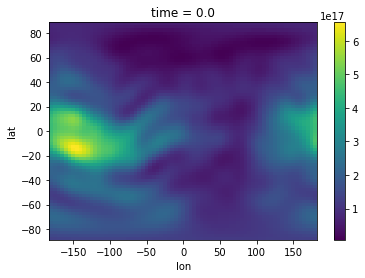

In [44]:
tecxr[0].plot()

In [45]:
tecxr

<xarray.DataArray (time: 25, lat: 71, lon: 73)>
array([[[  7.60000000e+16,   7.60000000e+16,   7.60000000e+16, ...,
           7.50000000e+16,   7.60000000e+16,   7.60000000e+16],
        [  7.70000000e+16,   7.80000000e+16,   7.90000000e+16, ...,
           7.50000000e+16,   7.60000000e+16,   7.70000000e+16],
        [  7.50000000e+16,   7.60000000e+16,   7.80000000e+16, ...,
           7.00000000e+16,   7.20000000e+16,   7.50000000e+16],
        ..., 
        [  1.59000000e+17,   1.61000000e+17,   1.63000000e+17, ...,
           1.53000000e+17,   1.56000000e+17,   1.59000000e+17],
        [  1.44000000e+17,   1.45000000e+17,   1.47000000e+17, ...,
           1.40000000e+17,   1.42000000e+17,   1.44000000e+17],
        [  1.33000000e+17,   1.33000000e+17,   1.34000000e+17, ...,
           1.31000000e+17,   1.32000000e+17,   1.33000000e+17]],

       [[  6.10000000e+16,   6.00000000e+16,   6.00000000e+16, ...,
           6.10000000e+16,   6.10000000e+16,   6.10000000e+16],
        [  6.40000000e+16,   6.30000000e+16,   6.20000000e+16, ...,
           6.50000000e+16,   6.40000000e+16,   6.40000000e+16],
        [  6.50000000e+16,   6.40000000e+16,   6.30000000e+16, ...,
           6.50000000e+16,   6.50000000e+16,   6.50000000e+16],
...
        [  1.77000000e+17,   1.82000000e+17,   1.87000000e+17, ...,
           1.65000000e+17,   1.71000000e+17,   1.77000000e+17],
        [  1.66000000e+17,   1.69000000e+17,   1.72000000e+17, ...,
           1.60000000e+17,   1.63000000e+17,   1.66000000e+17],
        [  1.56000000e+17,   1.57000000e+17,   1.58000000e+17, ...,
           1.54000000e+17,   1.55000000e+17,   1.56000000e+17]],

       [[  8.40000000e+16,   8.40000000e+16,   8.30000000e+16, ...,
           8.40000000e+16,   8.40000000e+16,   8.40000000e+16],
        [  8.90000000e+16,   8.90000000e+16,   8.90000000e+16, ...,
           8.70000000e+16,   8.80000000e+16,   8.90000000e+16],
        [  8.90000000e+16,   9.10000000e+16,   9.20000000e+16, ...,
           8.60000000e+16,   8.70000000e+16,   8.90000000e+16],
        ..., 
        [  1.73000000e+17,   1.77000000e+17,   1.80000000e+17, ...,
           1.66000000e+17,   1.70000000e+17,   1.73000000e+17],
        [  1.62000000e+17,   1.64000000e+17,   1.65000000e+17, ...,
           1.58000000e+17,   1.60000000e+17,   1.62000000e+17],
        [  1.49000000e+17,   1.50000000e+17,   1.50000000e+17, ...,
           1.48000000e+17,   1.49000000e+17,   1.49000000e+17]]])
Coordinates:
  * time     (time) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 20.0 21.0 22.0 23.0 24.0
  * lon      (lon) float64 -180.0 -175.0 -170.0 -165.0 ... 170.0 175.0 180.0
  * lat      (lat) float64 87.5 85.0 82.5 80.0 77.5 ... -80.0 -82.5 -85.0 -87.5

In [46]:
ionix_JHR = download_code_data_JHR(acqtime)

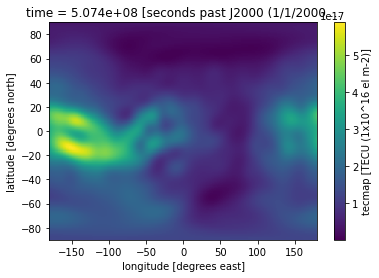

In [47]:
ds['tecmap'][0].plot(x='lon', y='lat')

In [48]:
ds

<xarray.Dataset>
Dimensions:    (nepochs: 96, nlats: 180, nlons: 360)
Coordinates:
    time       (nepochs) float64 5.074e+08 5.074e+08 ... 5.075e+08 5.075e+08
    lat        (nlats) float32 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
    lon        (nlons) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Dimensions without coordinates: nepochs, nlats, nlons
Data variables:
    varepochs  (nepochs) object ...
    tecmap     (nepochs, nlats, nlons) float32 3.7e+16 3.7e+16 ... 1.28e+17
    tecflag    (nepochs, nlats, nlons) int8 ...
Attributes:
    CreationDateUTC:  2023-03-15 21:40:25.142426
    OutputFileName:   jpld0300.16i.nc
    InputFileName:    160130_0000_160131_0000.tecgrds.txt
    Description:      This netCDF4 file was converted from tecgrds file, cont...

In [49]:
# def download_code_data_JHR(acqtime, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM'):
#     #lastrings = ['I', 'N']
#     ffound = False
#     if not ffound:
#         filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz' # TODO: check YMD
#         url = 'https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpld/' + str(acqtime.year) + '/' + filename
#         fullpath = os.path.join(storedir, filename)
#         ionix = fullpath[:-3]
#         print(filename)
#         if not os.path.exists(ionix):
#             if not os.path.exists(fullpath):
#                 # download this
#                 try:
#                     wgotfile = wget.download(url, out=storedir)
#                 except:
#                     print('error during wget download')
#                     ffound = False
#             if os.path.exists(fullpath):
#                 ffound = True
#         else:
#             ffound = True
#     if not ffound:
#         print('no CODE layer found for '+filename)
#         return False
#     if not os.path.exists(ionix):
#         rc = os.system('cd ' + storedir + '; 7za x ' + filename + ' >/dev/null 2>/dev/null; rm ' + fullpath)
#     if not os.path.exists(ionix):
#         print('ERROR: maybe you do not have 7za installed')
#         return False
#     return ionix
# a=download_code_data_JHR(acqtime)

In [50]:
# def get_vtec_from_JHR(acqtime, lat = 0, lon = 0, storedir = '/work/scratch-pw2/licsar/mnergiz/JPL_HR-GIM', return_fullxr = False):
#     """ This code helps to extract NASA JPL High Resolution vTEC values (15min, 1x1degree). https://sideshow.jpl.nasa.gov/pub/iono_daily/gim_for_research/jpli/
#     MNergizci, 17/03/2025, COMET, University of Leeds.

#     Args:
#         # acqtime (dt.datetime)
#         lat (float)
#         lon (float)
#         storedir (str)
#         return_fullxr (bool): if True, will return full TEC datacube
#     """
#     #D = acqtime.strftime('%Y%m%d')
#     #ipp = np.array([lat,lon])
#     # check if exists: filename = 'jpld'+ acqtime.strftime('%j') + '0.' + acqtime.strftime('%y')+'i.nc.gz'
#     fna = glob.glob(storedir + '/jpld' + acqtime.strftime('%j') + '0.' + acqtime.strftime('%y') + '*.nc')
#     if fna:
#         ionix = os.path.join(storedir,fna[0])
#     else:
#         # download:
#         ionix = download_code_data_JHR(acqtime, storedir)
#     if not ionix:
#         return False
#     print(ionix)
#     # Open the NetCDF file
#     ds = xr.open_dataset(ionix)

#     # Convert time epochs to readable datetime format, 15min resolution referenced to j2000 (1/1/2000 12:00 UT), 
#     time_values = ds['time'].values
#     #converting yyyy-mm-ddThh:mm:ss format. #TODO: We can change that regarding ML's wishes. I found this is clear for now.
#     converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')
#     #dataset2dataarray
#     tecxr_jhr = xr.DataArray(data=ds['tecmap'].values, dims=['time','lat','lon'],
#                         coords=dict(time=converted_times, lat= ds["lat"].values, lon= ds["lon"].values) )
#     tecxr_jhr=tecxr_jhr*1e+16 # from TECU
#     if return_fullxr:
#          return tecxr_jhr
#     else:
#         return get_vtec_from_tecxr(tecxr_jhr, acqtime, lat, lon)

# ###main

# tecxr_jhr2=get_vtec_from_JHR(acqtime, lat=0, lon=0, return_fullxr = True)

In [51]:
# tecxr_jhr2

In [52]:
# # Open the NetCDF file
# ds = xr.open_dataset(ionix_JHR)

# # Extract time values from the dataset
# time_values = ds['time'].values

# # Convert time epochs to readable datetime format
# converted_times = pd.to_datetime(time_values, origin='2000-01-01 12:00:00', unit='s')
# tecxr_jhr = xr.DataArray(data=ds['tecmap'].values, dims=['time','lat','lon'],
#                         coords=dict(time=converted_times, lat= ds["lat"].values, lon= ds["lon"].values) )
# tecxr_jhr=tecxr_jhr*1e+16 # from TECU

In [53]:
# tecxr_jhr[1].plot()

In [54]:
# "lat": ds["lat"].values, "lon": ds["lon"].values

In [55]:
# tecxr_jhr = xr.DataArray(data=ds['tecmap'].values, dims=['time','lat','lon'],
#                         # coords=dict(time=converted_times, lat= ds["lat"].values, lon= ds["lon"].values) )

In [56]:
# ds['tecmap'].values

In [57]:
# converted_times

In [58]:
# ds_new = xr.DataArray(
#     # ds['tecmap'][0].values, 
#     coords={"lat": ds["lat"].values, "lon": ds["lon"].values}, 
#     dims=["lat", "lon"]
# )
# # tecxr_da=tecxr[0]
# # tecxr_interp = tecxr_da.interp_like(ds_new, method='linear')
# # # Compute the difference
# # tec_difference = tecxr_interp-ds_new
